# 키워드/IP 이기종 네트워크 EDA — 성공/실패 패턴 & 모델 오분류 진단

> 확정 모델 **`v2_sweepA`**. 분석 단위를 *상품*이 아니라 **유사상품 엣지(`sim_kw`·`sim_ip`)를 만든 속성·IP 노드**로 옮겨, *키워드 관점*에서 성패 패턴과 오분류 원인을 규명. Run All 시 `report_assets/*.png` + `keyword_network_eda_report.md` 자동 생성.

**엣지 규칙(모델 충실)**: 모델은 키워드 **≥3 공유** 상품쌍에 `sim_kw`, IP **≥1 공유**에 `sim_ip`를 건다. 본 네트워크의 공동출현 엣지는 **그 엣지를 만들 때 기여한 키워드/IP**(=`A_PK@A_PKᵀ≥3` 상품쌍의 공유집합)에 한해 클리크로 구성. 추가로 원본 HIN 관계(`trend_to`·`ip_has_kw`·`ip_has_ip`)도 **관계 태그(rel)와 함께** 보존해 relation-aware로 해석.

In [1]:
# Phase 0 — 셋업
from pathlib import Path
import sys, collections
import numpy as np, pandas as pd, scipy.sparse as sp
from scipy.sparse.csgraph import connected_components
from scipy.stats import mannwhitneyu, pointbiserialr, spearmanr
from itertools import combinations
import matplotlib.pyplot as plt
import networkx as nx

ROOT = Path.cwd()
while not (ROOT/'src'/'models'/'hin_gnn.py').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
SHARE_HIN = ROOT/'7eleven_npd_share'/'data'/'processed'/'hin'
EXP_DIR   = ROOT/'experiments'/'results'/'v2_sweepA'
NB_DIR    = ROOT/'eda'/'network_eda_원준'
ASSETS    = NB_DIR/'report_assets'; ASSETS.mkdir(parents=True, exist_ok=True)
try: plt.rcParams['font.family'] = 'Malgun Gothic'
except Exception: pass
plt.rcParams['axes.unicode_minus'] = False
def savefig(fig, name): fig.savefig(ASSETS/name, dpi=120, bbox_inches='tight')
THR = 0.7049
def nid(x):
    try: return str(int(float(x)))
    except Exception: return str(x)
print('ROOT=', ROOT, '| THR=', THR)

ROOT= C:\Users\alexj\2026_캡스톤_디자인\세븐일레븐_프로젝트\세븐일레븐_분석_B팀 | THR= 0.7049


## Phase 1 — 입력 로드 · 전 상품 quad · 기여 노드/엣지(strict)
전체 상품(train+val+test) 예측을 **THR=0.7049**(대시보드 운영점)로 잘라 TP/FP/FN/TN을 매긴다.

In [2]:
pk = pd.read_parquet(SHARE_HIN/'product_keyword_edges_final.parquet'); pk['pid'] = pk['ITEM_CD'].map(nid)
pi = pd.read_parquet(SHARE_HIN/'product_ip_edges_final.parquet');      pi['pid'] = pi['ITEM_CD'].map(nid)
knodes = pd.read_parquet(SHARE_HIN/'keyword_nodes_final.parquet')
tk = pd.read_parquet(SHARE_HIN/'trend_keyword_edges_final.parquet')
ik = pd.read_parquet(SHARE_HIN/'ip_keyword_edges_final.parquet')
ii = pd.read_parquet(SHARE_HIN/'ip_ip_edges_final.parquet')          # 원본 IP-IP (Rev2)
trend_set = set(knodes.loc[knodes['is_trend_keyword'] == 1, 'keyword'].astype(str))

sc = pd.read_parquet(EXP_DIR/'learned_product_scores.parquet'); sc['pid'] = sc['ITEM_CD'].map(nid)
sc['pred'] = (sc['pred_success_prob'] >= THR).astype(int); sc['yt'] = sc['y_true'].astype(int)
sc['quad'] = np.where((sc.pred==1)&(sc.yt==1),'TP', np.where((sc.pred==1)&(sc.yt==0),'FP',
                np.where((sc.pred==0)&(sc.yt==1),'FN','TN')))
y_map = dict(zip(sc['pid'], sc['yt'])); pred_map = dict(zip(sc['pid'], sc['pred'])); quad_map = dict(zip(sc['pid'], sc['quad']))
QUAD = sc['quad'].value_counts().to_dict(); BASE = sc['yt'].mean()
print('전 상품 quad:', QUAD, '| n=', len(sc), '| 기저성공률=', round(BASE,3))

전 상품 quad: {'TN': 3412, 'TP': 719, 'FN': 478, 'FP': 424} | n= 5033 | 기저성공률= 0.238


In [3]:
# strict 기여 노드/엣지
prod_kw = pk.groupby('pid')['keyword'].apply(lambda s: set(map(str, s))).to_dict()
prod_ip = pi.groupby('pid')['ip_name'].apply(lambda s: set(map(str, s))).to_dict()
prods = sorted(prod_kw); pidx = {p:i for i,p in enumerate(prods)}
kws = sorted(set(pk['keyword'].astype(str))); kidx = {k:i for i,k in enumerate(kws)}
A = sp.csr_matrix((np.ones(len(pk)), (pk['pid'].map(pidx), pk['keyword'].astype(str).map(kidx))), shape=(len(prods), len(kws)))
S = (A @ A.T).tocoo(); mask = (S.row < S.col) & (S.data >= 3)
KKedges = set(); kw_used = set()
for i, j in zip(S.row[mask], S.col[mask]):
    sset = prod_kw[prods[i]] & prod_kw[prods[j]]; kw_used |= sset
    for a, b in combinations(sorted(sset), 2): KKedges.add((a, b))

ipl = sorted(prod_ip); Pidx = {p:i for i,p in enumerate(ipl)}
ips = sorted(set(pi['ip_name'].astype(str))); iidx = {k:i for i,k in enumerate(ips)}
Bm = sp.csr_matrix((np.ones(len(pi)), (pi['pid'].map(Pidx), pi['ip_name'].astype(str).map(iidx))), shape=(len(ipl), len(ips)))
Sip = (Bm @ Bm.T).tocoo(); m1 = (Sip.row<Sip.col)&(Sip.data>=1); m2 = (Sip.row<Sip.col)&(Sip.data>=2)
ip_used = set(); IIedges = set()
for i, j in zip(Sip.row[m1], Sip.col[m1]): ip_used |= (prod_ip[ipl[i]] & prod_ip[ipl[j]])
for i, j in zip(Sip.row[m2], Sip.col[m2]):
    for a, b in combinations(sorted(prod_ip[ipl[i]] & prod_ip[ipl[j]]), 2): IIedges.add((a, b))
print(f'기여 키워드 {len(kw_used)}/{len(kws)} · IP {len(ip_used)}/{len(ips)} | 공동출현 KK {len(KKedges)} · II {len(IIedges)}')

기여 키워드 1297/1923 · IP 139/216 | 공동출현 KK 15921 · II 31


In [4]:
# 노드 피처 테이블 (이웃 상품 = 키워드/IP 보유 상품 전체)
kw2prods = {k:set(g) for k,g in pk.groupby('keyword')['pid']}
ip2prods = {k:set(g) for k,g in pi.groupby('ip_name')['pid']}
def uid_of(name, is_kw): return name if is_kw else 'IP::' + name
def node_feats(name, prod_ids, is_kw):
    ys=[y_map[p] for p in prod_ids if p in y_map]; ps=[pred_map[p] for p in prod_ids if p in pred_map]
    qs=[quad_map[p] for p in prod_ids if p in quad_map]; n=len(ys)
    if n==0: return None
    nFP,nFN,nTP,nTN = qs.count('FP'),qs.count('FN'),qs.count('TP'),qs.count('TN')
    F1,F2 = float(np.mean(ys)), float(np.mean(ps))
    return dict(uid=uid_of(name,is_kw), name=name, type='keyword' if is_kw else 'ip', support=n,
                F1=F1, F2=F2, bias=F2-F1, n_FP=nFP, n_FN=nFN, n_TP=nTP, n_TN=nTN,
                FP율=nFP/n, FN율=nFN/n, trend=int(name in trend_set) if is_kw else 0)
rows=[node_feats(k, kw2prods.get(k,set()), True) for k in sorted(kw_used)]
rows+=[node_feats(x, ip2prods.get(x,set()), False) for x in sorted(ip_used)]
nf = pd.DataFrame([r for r in rows if r]).set_index('uid')
print('노드 피처:', nf.shape, '| 스팟체크 고창', round(nf.loc['고창','F1'],2), '캔', round(nf.loc['캔','F1'],2), '관람', round(nf.loc['관람','F1'],2))
nf.head()

노드 피처: (1436, 13) | 스팟체크 고창 0.8 캔 0.0 관람 1.0


,name,type,support,F1,F2,bias,n_FP,n_FN,n_TP,n_TN,FP율,FN율,trend
uid,,,,,,,,,,,,,
1등급원유,1등급원유,keyword,2,1.000000,1.000000,0.0,0,0,2,0,0.000000,0.000000,0
1인,1인,keyword,18,0.111111,0.111111,0.0,0,0,2,16,0.000000,0.000000,1
?,?,keyword,26,0.307692,0.307692,0.0,3,3,5,15,0.115385,0.115385,0
BBQ,BBQ,keyword,5,0.200000,0.400000,0.2,2,1,0,2,0.400000,0.200000,0
CAFE25,CAFE25,keyword,8,0.375000,0.375000,0.0,0,0,3,5,0.000000,0.000000,0


## Phase 2 — 이기종 네트워크 (`networkx`, 비가중, relation-aware)
엣지에 `rel` 태그 부착. **유사성 관계**(`kw_cooc`·`ip_cooc`, sim 쌍대)와 **원본 소속 관계**(`trend_to`·`ip_has_kw`·`ip_has_ip`)를 함께 보존하되 분석에서 구분.

In [5]:
G = nx.Graph()
for node, r in nf.iterrows():
    G.add_node(node, **{c:r[c] for c in ['name','type','F1','F2','bias','n_FP','n_FN','support','trend']})
for a,b in sorted(KKedges):    # 정렬→그래프 순서 고정(재현성)
    if a in G and b in G: G.add_edge(a,b, rel='kw_cooc')
for a,b in sorted(IIedges):
    if 'IP::'+a in G and 'IP::'+b in G: G.add_edge('IP::'+a,'IP::'+b, rel='ip_cooc')
for a,b in zip(tk['src_keyword'].astype(str), tk['tgt_keyword'].astype(str)):
    if a in G and b in G and a!=b: G.add_edge(a,b, rel='trend_to')
for a,b in zip(ik['ip_name'].astype(str), ik['keyword'].astype(str)):
    if 'IP::'+a in G and b in G: G.add_edge('IP::'+a,b, rel='ip_has_kw')
for a,b in zip(ii['src_ip'].astype(str), ii['tgt_ip'].astype(str)):           # Rev2 원본 IP-IP
    if 'IP::'+a in G and 'IP::'+b in G and a!=b: G.add_edge('IP::'+a,'IP::'+b, rel='ip_has_ip')
RELC = collections.Counter(d['rel'] for _,_,d in G.edges(data=True))
ncomp,lab = connected_components(nx.to_scipy_sparse_array(G), directed=False)
GIANT = collections.Counter(lab).most_common(1)[0][1]
print(f'노드 {G.number_of_nodes()} 엣지 {G.number_of_edges()} | 컴포넌트 {ncomp} 최대 {GIANT} ({GIANT/G.number_of_nodes():.1%})')
print('관계별 엣지:', dict(RELC))

노드 1436 엣지 17269 | 컴포넌트 11 최대 1426 (99.3%)
관계별 엣지: {'kw_cooc': 15171, 'trend_to': 1612, 'ip_has_kw': 455, 'ip_cooc': 31}


## 분석 A — 성공/실패 키워드는 무엇과 붙는가 (동류성)
🎯 성공률 높은 키워드끼리 붙는가 회피하는가. 🔬 동류성 계수(유사성망 vs 전체망) + 클래스 혼합 + **공유상품 confound 통제**.

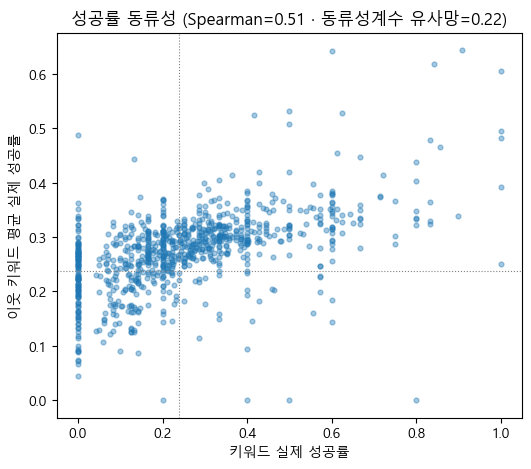

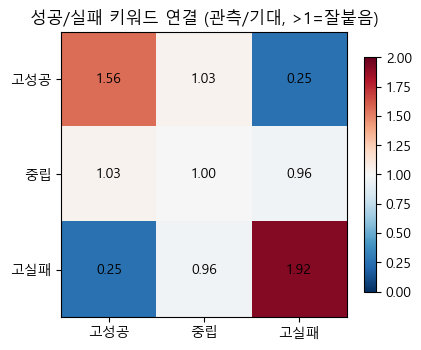

동류성계수: 유사망(kw_cooc)=0.216 / 전체망=0.192 | 자기-이웃 Spearman=0.506
혼합 관측/기대:
       고성공    중립   고실패
고성공  1.56  1.03  0.25
중립   1.03  1.00  0.96
고실패  0.25  0.96  1.92


In [6]:
# 동류성: kw_cooc-only(유사성망) 와 full-graph 둘 다
Gk = G.edge_subgraph([(u,v) for u,v,d in G.edges(data=True) if d['rel']=='kw_cooc']).copy()
assort_full = nx.numeric_assortativity_coefficient(G,'F1')
assort_kw   = nx.numeric_assortativity_coefficient(Gk,'F1')
nbrF1 = {u: np.mean([G.nodes[v]['F1'] for v in G.neighbors(u)]) for u in G.nodes() if G.degree(u)>0}
sub = nf.loc[list(nbrF1)].copy(); sub['nbrF1']=[nbrF1[u] for u in sub.index]
rho,pval = spearmanr(sub['F1'], sub['nbrF1'])
figA,axA = plt.subplots(figsize=(6,5)); ms = sub['support']>=5
axA.scatter(sub.loc[ms,'F1'], sub.loc[ms,'nbrF1'], s=12, alpha=.4)
axA.axhline(BASE,color='gray',ls=':',lw=.8); axA.axvline(BASE,color='gray',ls=':',lw=.8)
axA.set_xlabel('키워드 실제 성공률'); axA.set_ylabel('이웃 키워드 평균 실제 성공률')
axA.set_title(f'성공률 동류성 (Spearman={rho:.2f} · 동류성계수 유사망={assort_kw:.2f})'); savefig(figA,'kwnet_assort.png'); plt.show()

THR_HIGH = float(nf[(nf['type']=='keyword') & (nf['support']>=5)]['F1'].quantile(0.90))  # 고성공=상위10%
def klass(f1,sup):
    if sup<5: return '저표본'
    return '고성공' if f1>=THR_HIGH else ('고실패' if f1<=0.10 else '중립')
nf['class']=[klass(f,s) for f,s in zip(nf['F1'],nf['support'])]
CL=['고성공','중립','고실패']; cix={c:i for i,c in enumerate(CL)}; M=np.zeros((3,3))
for u,v in Gk.edges():
    cu,cv = nf.loc[u,'class'], nf.loc[v,'class']
    if cu in cix and cv in cix: M[cix[cu],cix[cv]]+=1; M[cix[cv],cix[cu]]+=1
Exp=np.outer(M.sum(1),M.sum(1))/M.sum(); RAT=np.divide(M,Exp,out=np.zeros_like(M),where=Exp>0)
figM,axM=plt.subplots(figsize=(4.6,3.8)); im=axM.imshow(RAT,cmap='RdBu_r',vmin=0,vmax=2)
axM.set_xticks(range(3)); axM.set_xticklabels(CL); axM.set_yticks(range(3)); axM.set_yticklabels(CL)
for i in range(3):
    for j in range(3): axM.text(j,i,f'{RAT[i,j]:.2f}',ha='center',va='center',fontsize=10)
axM.set_title('성공/실패 키워드 연결 (관측/기대, >1=잘붙음)'); plt.colorbar(im,ax=axM,shrink=.8); savefig(figM,'kwnet_mix.png'); plt.show()
print(f'동류성계수: 유사망(kw_cooc)={assort_kw:.3f} / 전체망={assort_full:.3f} | 자기-이웃 Spearman={rho:.3f}')
print('혼합 관측/기대:\n', pd.DataFrame(RAT,index=CL,columns=CL).round(2))

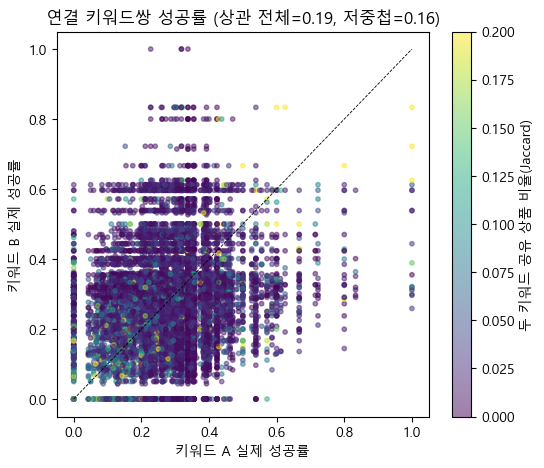

연결쌍 |Δ실제성공률| 평균 0.131 (랜덤쌍 ~0.195) | 공유상품 Jaccard 중앙 0.016 (저중첩<0.1 비율 96%)
성공률 상관: 전체 0.192 → 공유상품 거의없는쌍(Jaccard<0.1) 0.163  ⇒ 동류성은 공유상품 산물 아님


In [7]:
# Rev2 — 공유상품 confound 통제: 연결 키워드쌍의 성공률 유사성이 '같은 상품 공유'의 산물인가?
F1kw = nf[nf['type']=='keyword']['F1']
E1=[];E2=[];JAC=[]
for a,b in KKedges:
    if a in F1kw.index and b in F1kw.index and nf.loc[a,'support']>=5 and nf.loc[b,'support']>=5:
        Pa,Pb=kw2prods[a],kw2prods[b]
        E1.append(F1kw[a]); E2.append(F1kw[b]); JAC.append(len(Pa&Pb)/len(Pa|Pb))
E1,E2,JAC=np.array(E1),np.array(E2),np.array(JAC); dF=np.abs(E1-E2)
PEAR_ALL=np.corrcoef(E1,E2)[0,1]; lo=JAC<0.1; PEAR_LOW=np.corrcoef(E1[lo],E2[lo])[0,1]
JAC_MED=np.median(JAC); DF_MEAN=dF.mean()
figJ,axJ=plt.subplots(figsize=(6,5)); s=axJ.scatter(E1,E2,c=JAC,cmap='viridis',vmin=0,vmax=0.2,s=10,alpha=.5)
axJ.plot([0,1],[0,1],'k--',lw=.6); axJ.set_xlabel('키워드 A 실제 성공률'); axJ.set_ylabel('키워드 B 실제 성공률')
axJ.set_title(f'연결 키워드쌍 성공률 (상관 전체={PEAR_ALL:.2f}, 저중첩={PEAR_LOW:.2f})'); plt.colorbar(s,ax=axJ,label='두 키워드 공유 상품 비율(Jaccard)')
savefig(figJ,'kwnet_assort_jaccard.png'); plt.show()
print(f'연결쌍 |Δ실제성공률| 평균 {DF_MEAN:.3f} (랜덤쌍 ~0.195) | 공유상품 Jaccard 중앙 {JAC_MED:.3f} (저중첩<0.1 비율 {lo.mean():.0%})')
print(f'성공률 상관: 전체 {PEAR_ALL:.3f} → 공유상품 거의없는쌍(Jaccard<0.1) {PEAR_LOW:.3f}  ⇒ 동류성은 공유상품 산물 아님')

## 분석 B — 트렌드 여부 ↔ 성공
🎯 트렌드 키워드가 성공과 상관있나. 🔬 trend vs non-trend 실제 성공률(Mann–Whitney)+point-biserial. (IP는 trend 무관 → 키워드 한정)

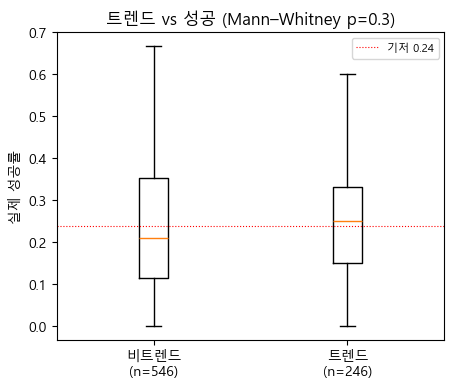

트렌드 실제성공률 중앙 0.250(n=246) vs 비트렌드 0.209(n=546) | MWU p=0.296 | 상관 r=-0.017


In [8]:
kw_only = nf[(nf['type']=='keyword') & (nf['support']>=5)]
tr1 = kw_only.loc[kw_only['trend']==1,'F1']; tr0 = kw_only.loc[kw_only['trend']==0,'F1']
U,pmw = mannwhitneyu(tr1,tr0,alternative='two-sided'); pb,ppb = pointbiserialr(kw_only['trend'],kw_only['F1'])
figB,axB=plt.subplots(figsize=(5,4))
axB.boxplot([tr0,tr1], tick_labels=[f'비트렌드\n(n={len(tr0)})', f'트렌드\n(n={len(tr1)})'], showfliers=False)
axB.axhline(BASE,color='r',ls=':',lw=.8,label=f'기저 {BASE:.2f}'); axB.set_ylabel('실제 성공률')
axB.set_title(f'트렌드 vs 성공 (Mann–Whitney p={pmw:.2g})'); axB.legend(fontsize=8); savefig(figB,'kwnet_trend.png'); plt.show()
print(f'트렌드 실제성공률 중앙 {tr1.median():.3f}(n={len(tr1)}) vs 비트렌드 {tr0.median():.3f}(n={len(tr0)}) | MWU p={pmw:.3f} | 상관 r={pb:.3f}')

## 분석 C — Louvain 군집 (modularity 최대화)
🎯 뚜렷한 군집·성패 분리 여부 + 군집이 유사성/속성 중 무엇으로 묶였나. 🔬 비가중 Louvain → Q·전 군집 프로파일(관계 구성 포함)·군집별 노드 샘플.

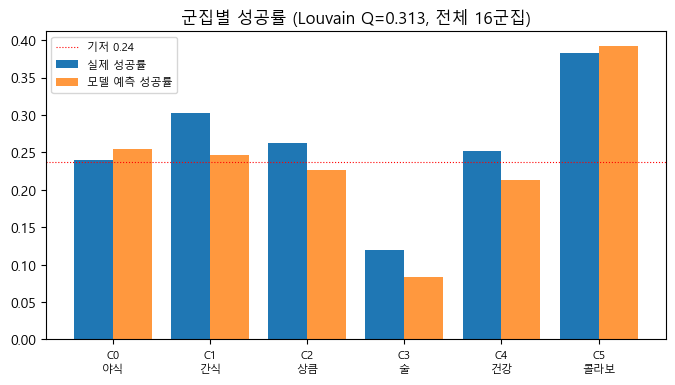

군집수 16 · modularity Q=0.313
 군집           군집명   n  실제성공률  예측성공률     격차   FP   FN  트렌드      주도관계                                    대표
  0        식사·간편식 454  0.240  0.254  0.014 1316 1160 0.24 유사주도(89%)              야식, 식사, 매콤, 간편, 고기, 짭조름함
  1        간식·디저트 427  0.303  0.247 -0.056 1516 1708 0.22 유사주도(82%)             간식, 달콤, 디저트, 부드러움, 고소, 초코
  2        음료·아이스 232  0.263  0.227 -0.036  477  623 0.22 유사주도(93%)            상큼, 음료, 아이스크림, 아이스, 딸기, 시즌
  3 주류(와인·위스키·맥주) 197  0.120  0.084 -0.037  140  297 0.10 유사주도(96%)                술, 와인, 위스키, 풍미, 레드, 선물
  4       건강·다이어트  69  0.252  0.213 -0.039   77   95 0.17 유사주도(90%)         건강, 다이어트, 샐러드, 단백질, 샌드위치, 견과류
  5    콜라보·캐릭터 IP  47  0.383  0.392  0.009   90   46 0.00 속성주도(35%) 콜라보, KBO, 맛삼춘, 케이팝데몬헌터스, 흑백요리사, 캐치티니핑
  6            동아   1  0.444  0.222 -0.222    1    3 0.00         -                                    동아
  7           먼작귀   1  0.000  0.000  0.000    0    0 0.00         -                                   먼작귀
  8           서울대 

In [9]:
comms = sorted(nx.community.louvain_communities(G, seed=42), key=len, reverse=True)
COMM_NAMES = {0:'식사·간편식', 1:'간식·디저트', 2:'음료·아이스', 3:'주류(와인·위스키·맥주)', 4:'건강·다이어트', 5:'콜라보·캐릭터 IP'}
def comm_name(ci, s2):
    if ci in COMM_NAMES: return COMM_NAMES[ci]
    return s2.sort_values('support', ascending=False).iloc[0]['name'] if len(s2) else '-'
Q = nx.community.modularity(G, comms)
cmap_id = {u:ci for ci,c in enumerate(comms) for u in c}; nf['comm']=[cmap_id.get(u,-1) for u in nf.index]
SIM_RELS={'kw_cooc','ip_cooc'}
def relmix(c):
    sub=G.subgraph(c); cnt=collections.Counter(d['rel'] for _,_,d in sub.edges(data=True)); tot=sum(cnt.values())
    if tot==0: return '-', 0
    sim=sum(v for k,v in cnt.items() if k in SIM_RELS)/tot
    return ('유사주도' if sim>=0.5 else '속성주도')+f'({sim:.0%})', tot
prof=[]
for ci,c in enumerate(comms):                       # Rev3 — 전 군집 출력 (필터 제거)
    s2=nf.loc[[u for u in c if u in nf.index]]; lab,_=relmix(c)
    prof.append(dict(군집=ci, 군집명=comm_name(ci, s2), n=len(s2), 실제성공률=round(s2['F1'].mean(),3), 예측성공률=round(s2['F2'].mean(),3),
                     격차=round(s2['bias'].mean(),3), FP=int(s2['n_FP'].sum()), FN=int(s2['n_FN'].sum()),
                     트렌드=round(s2['trend'].mean(),2), 주도관계=lab,
                     대표=', '.join(s2.sort_values('support',ascending=False).head(6)['name'])))
profdf = pd.DataFrame(prof)
big = profdf[profdf['n']>=10].reset_index(drop=True)
figC,axC=plt.subplots(figsize=(8,4)); x=np.arange(len(big))
axC.bar(x-0.2, big['실제성공률'], 0.4, label='실제 성공률'); axC.bar(x+0.2, big['예측성공률'], 0.4, label='모델 예측 성공률', alpha=.8)
axC.axhline(BASE,color='r',ls=':',lw=.8,label=f'기저 {BASE:.2f}'); axC.set_xticks(x)
axC.set_xticklabels([f"C{int(big.iloc[i]['군집'])}\n{big.iloc[i]['대표'].split(',')[0]}" for i in range(len(big))], fontsize=8)
axC.set_title(f'군집별 성공률 (Louvain Q={Q:.3f}, 전체 {len(comms)}군집)'); axC.legend(fontsize=8); savefig(figC,'kwnet_comm.png'); plt.show()
print(f'군집수 {len(comms)} · modularity Q={Q:.3f}'); print(profdf.to_string(index=False))

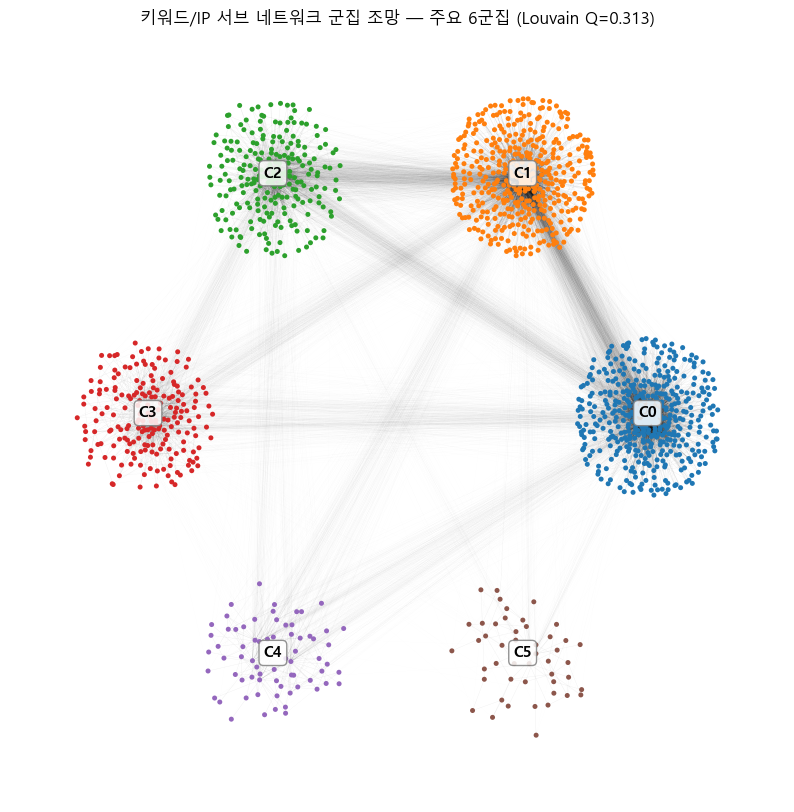

In [10]:
# 군집 전체 조망 — 주요 군집을 링 위 별도 영역에 배치(군집 내부 spring) → 시각적 분리 강조
import math
gc = max(nx.connected_components(G), key=len)        # giant component만(소형 분리 군집 제외)
H = G.subgraph(gc)
big_ids = [int(r['군집']) for _, r in big.iterrows()]  # n>=10 주요 군집
cmap = plt.get_cmap('tab10')
pos = {}; color = {}; R = 6.0
for k, ci in enumerate(big_ids):
    members = [u for u in comms[ci] if u in H]
    p = nx.spring_layout(H.subgraph(members), seed=42, k=0.6)
    ang = 2*math.pi*k/len(big_ids); center = np.array([math.cos(ang), math.sin(ang)])*R
    for u, xy in p.items():
        pos[u] = np.array(xy)*1.7 + center; color[u] = cmap(k % 10)
ndraw = [u for u in H if u in pos]
intra = [(u, v) for u, v in H.edges() if u in color and v in color and color[u] == color[v]]
inter = [(u, v) for u, v in H.edges() if u in color and v in color and not color[u] == color[v]]
figN, axN = plt.subplots(figsize=(10, 10))
nx.draw_networkx_edges(H, pos, edgelist=inter, ax=axN, alpha=0.012, width=0.2, edge_color='gray')
nx.draw_networkx_edges(H, pos, edgelist=intra, ax=axN, alpha=0.06, width=0.3)
nx.draw_networkx_nodes(H, pos, nodelist=ndraw, ax=axN, node_size=13, linewidths=0,
                       node_color=[color[u] for u in ndraw])
for k, ci in enumerate(big_ids):
    mem = [u for u in comms[ci] if u in pos]
    cx = np.mean([pos[u][0] for u in mem]); cy = np.mean([pos[u][1] for u in mem])
    axN.text(cx, cy, f"C{ci}", fontsize=11, weight='bold', ha='center',
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.85))
axN.set_title(f'키워드/IP 서브 네트워크 군집 조망 — 주요 {len(big_ids)}군집 (Louvain Q={Q:.3f})'); axN.axis('off')
savefig(figN, 'kwnet_network.png'); plt.show()

In [11]:
# Rev3 — 모든 군집의 실제 노드+피처 샘플
for _, r in profdf.iterrows():
    s2 = nf[nf['comm']==r['군집']].sort_values('support', ascending=False)
    disp = s2.head(8)[['name','type','support','F1','F2','bias','n_FP','n_FN','trend']].rename(
        columns={'name':'노드','type':'타입','support':'상품수','F1':'실제성공률','F2':'예측성공률','bias':'격차','trend':'트렌드'})
    print(f"\n=== 군집 C{int(r['군집'])} (n={r['n']}, 실제성공률={r['실제성공률']}, {r['주도관계']}) 대표: {r['대표']} ===")
    print(disp.to_string(index=False))


=== 군집 C0 (n=454, 실제성공률=0.24, 유사주도(89%)) 대표: 야식, 식사, 매콤, 간편, 고기, 짭조름함 ===
  노드      타입  상품수    실제성공률    예측성공률        격차  n_FP  n_FN  트렌드
  야식 keyword  780 0.319231 0.338462  0.019231   104    89    0
  식사 keyword  553 0.296564 0.325497  0.028933    64    48    1
  매콤 keyword  494 0.311741 0.297571 -0.014170    52    59    1
  간편 keyword  444 0.227477 0.202703 -0.024775    25    36    0
  고기 keyword  416 0.211538 0.211538  0.000000    31    31    0
짭조름함 keyword  364 0.401099 0.497253  0.096154    72    37    0
   밥 keyword  345 0.237681 0.255072  0.017391    32    26    1
  치즈 keyword  327 0.287462 0.327217  0.039755    39    26    1

=== 군집 C1 (n=427, 실제성공률=0.303, 유사주도(82%)) 대표: 간식, 달콤, 디저트, 부드러움, 고소, 초코 ===
  노드      타입  상품수    실제성공률    예측성공률        격차  n_FP  n_FN  트렌드
  간식 keyword 2476 0.337641 0.337641  0.000000   300   300    1
  달콤 keyword 1296 0.354938 0.372685  0.017747   187   164    1
 디저트 keyword  716 0.261173 0.231844 -0.029330    57    78    0
부드러움 keyword  687 0.423581 0.

## 분석 D — 모델이 가른 패턴 & 오분류 특징
🎯 모델이 과대/과소평가하는 키워드와, 정확히 잡아낸 키워드. 🔬 격차=예측−실제 (양수=과대/FP, 음수=과소/FN, ≈0=정확).

C:\Users\alexj\AppData\Local\Temp\ipykernel_36244\1968725715.py:22: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  def savefig(fig, name): fig.savefig(ASSETS/name, dpi=120, bbox_inches='tight')
C:\Users\alexj\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


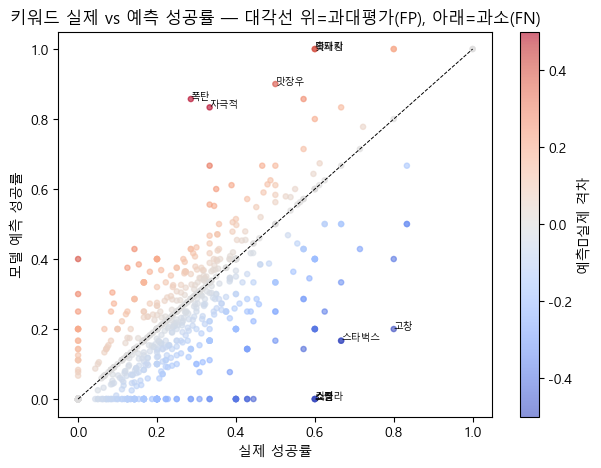

과대평가(FP유발) top: ['폭탄', '자극적', '맛장우', '흑돼지', '맛자랑', '의성', '콤보', '크리스마스', '홈런', '로스트', '맥시칸', '치폴레']
과소평가(FN유발) top: ['고창', '스팀', '쇼콜라', '킷캣', '스타벅스', '더킹', '에이스', '프로즌', '두바이', '라이트', '박카스', '버블']

정확 포착 키워드(|예측-실제|<=0.02): 271개
 정확히 잡은 성공 키워드: ['생크림', '커스터드', '참기름', '명란', '와사비', '랑그드샤', '메밀', '프링글스', '말이', '큐브', '녹진함', '레드벨벳', '시그니처', '로코모코', '관람']
 정확히 잡은 실패 키워드: ['전통', '캔', '피치', '다리', '찌개', '대용량', '콩', '하림', '블렌디드', '곰', '식빵', '시트러스', '페어링', '대파', '빅']


In [12]:
nfk = nf[(nf['type']=='keyword') & (nf['support']>=5)].copy()
over = nfk.sort_values('bias', ascending=False).head(15); under = nfk.sort_values('bias').head(15)
figD,axD=plt.subplots(figsize=(7,5))
sc2 = axD.scatter(nfk['F1'], nfk['F2'], c=nfk['bias'], cmap='coolwarm', vmin=-.5, vmax=.5, s=14, alpha=.6)
axD.plot([0,1],[0,1],'k--',lw=.7); axD.set_xlabel('실제 성공률'); axD.set_ylabel('모델 예측 성공률')
for nm in list(over['name'][:5])+list(under['name'][:5]):
    rr=nfk[nfk['name']==nm].iloc[0]; axD.annotate(nm,(rr['F1'],rr['F2']),fontsize=7)
axD.set_title('키워드 실제 vs 예측 성공률 — 대각선 위=과대평가(FP), 아래=과소(FN)'); plt.colorbar(sc2,ax=axD,label='예측−실제 격차')
savefig(figD,'kwnet_bias.png'); plt.show()
print('과대평가(FP유발) top:', list(over['name'][:12]))
print('과소평가(FN유발) top:', list(under['name'][:12]))

# Rev3 — 모델이 정확히 잡아낸 키워드 (예측≈실제)
acc = nfk[nfk['bias'].abs()<=0.02].copy()
acc_succ = acc[acc['F1']>=0.45].sort_values('support',ascending=False)
acc_fail = acc[acc['F1']<=0.10].sort_values('support',ascending=False)
print(f'\n정확 포착 키워드(|예측-실제|<=0.02): {len(acc)}개')
print(' 정확히 잡은 성공 키워드:', list(acc_succ['name'][:15]))
print(' 정확히 잡은 실패 키워드:', list(acc_fail['name'][:15]))

## 리포트 생성
아래 셀이 `keyword_network_eda_report.md`를 노트북 수치와 동기화하여 생성(읽기 쉬운 라벨·그림 캡션 포함).

In [13]:
L=[]; A=L.append
A('# 키워드/IP 이기종 네트워크 EDA — 성공/실패 패턴 & 모델 오분류 진단\n')
A(f'> 모델 `v2_sweepA` · 전체 상품 {len(sc):,}개 · 운영 임계값 0.7049 · 노드=기여 키워드 {int((nf.type=="keyword").sum())}+IP {int((nf.type=="ip").sum())} · Run All 자동 생성.\n')
A('## 0. 분석 개요\n')
A('모델은 유사상품(공유키워드 `sim_kw`·공유IP `sim_ip`)으로 성패를 가른다. 분석 단위를 그 엣지를 만든 **속성·IP 노드**로 옮겨, 키워드 관점에서 성패 패턴과 오분류를 본다. 공동출현 엣지는 **키워드 ≥3 공유 상품쌍의 공유집합**(모델 임계값 기여분)으로 구성, 원본 관계(`trend_to`·`ip_has_kw`·`ip_has_ip`)는 관계 태그와 함께 보존.\n')
A(f'- 네트워크: **{G.number_of_nodes():,} 노드 · {G.number_of_edges():,} 엣지**, 최대 컴포넌트 {GIANT/G.number_of_nodes():.1%}. 기여 안 한 키워드 {len(kws)-len(kw_used)}개 제외.\n')
A(f'- 전 상품 혼동: 정답성공 {QUAD.get("TP",0)} · 낚인실패(FP) {QUAD.get("FP",0)} · 놓친성공(FN) {QUAD.get("FN",0)} · 정답실패 {QUAD.get("TN",0)} (기저성공률 {BASE:.3f}).\n')

_relc = RELC
_nodes_tbl = pd.DataFrame([
    ['keyword (속성)', 'sim_kw 기여 키워드 — 키워드 ≥3 공유 상품쌍의 공유집합에 등장', int((nf['type']=='keyword').sum())],
    ['ip', 'sim_ip 기여 IP — IP ≥1 공유 상품쌍에 등장', int((nf['type']=='ip').sum())],
], columns=['노드 타입','정의','개수'])
_feat_tbl = pd.DataFrame([
    ['실제 성공률', '이웃 상품(키워드/IP 보유 상품)이 실제로 성공한 비율'],
    ['모델 예측 성공률', '이웃 상품 중 모델이 성공으로 예측(확률≥0.7049)한 비율'],
    ['낚인 실패(FP) 수 / 놓친 성공(FN) 수', '이웃 상품 중 오분류 절대 개수'],
    ['FP율 / FN율', '오분류 수를 이웃 수로 나눈 비율(degree 보정)'],
    ['예측−실제 격차', '양수=모델 과대평가(FP쪽) · 음수=과소평가(FN쪽) · 0=정확'],
    ['트렌드', '트렌드 키워드 여부(IP 노드는 0)'],
    ['상품수(support)', '집계에 쓰인 이웃 상품 수'],
], columns=['피처','정의'])
_edge_tbl = pd.DataFrame([
    ['kw_cooc (유사성)', '키워드 ≥3 공유 상품쌍의 공유 키워드집합 내부 클리크', _relc.get('kw_cooc',0)],
    ['ip_cooc (유사성)', 'IP ≥2 공유 상품쌍의 공유 IP집합 내부 클리크', _relc.get('ip_cooc',0)],
    ['trend_to (원본)', '트렌드키워드 → 속성키워드', _relc.get('trend_to',0)],
    ['ip_has_kw (원본)', 'IP → 보유 키워드', _relc.get('ip_has_kw',0)],
    ['ip_has_ip (원본)', 'IP → 연관 IP', _relc.get('ip_has_ip',0)],
], columns=['엣지 타입','구성 규칙','개수'])
A('\n### 분석 구성 — 각 분석의 목적\n')
A('| 분석 | 핵심 질문(목적) |\n|---|---|\n'
  '| **A. 동류성** | 성공/실패 키워드가 서로 끌리나 회피하나 → 키워드 공간이 성패로 분리돼 있는가 |\n'
  '| **B. 트렌드** | 트렌드 여부가 성공과 상관있나 → 트렌드를 성공 신호로 쓸 수 있는가 |\n'
  '| **C. 군집** | 키워드가 의미 군집으로 갈리고 군집마다 성패가 다른가 → 어떤 컨셉군이 성공/실패인가 |\n'
  '| **D. 모델·오분류** | 모델이 어떤 키워드를 과대/과소/정확 평가하나 → FP·FN 유발 키워드 장부 |\n')
A('\n### 네트워크 기초 통계\n')
A('**노드** — 이기종 2종, 총 %d개:\n' % G.number_of_nodes()); A(_nodes_tbl.to_markdown(index=False)+'\n')
A('\n**노드 피처** — 각 노드(키워드/IP)가 보유:\n'); A(_feat_tbl.to_markdown(index=False)+'\n')
A('\n**엣지** — 총 %d개(유사성=모델이 중시한 sim 쌍대, 원본=소속 관계):\n' % G.number_of_edges()); A(_edge_tbl.to_markdown(index=False)+'\n')

A('## A. 성공/실패 키워드의 동류성\n')
A('🎯 **목적**: 성공률이 비슷한 키워드끼리 연결되는지(동류) 섞이는지 보아, 키워드 공간이 성패로 분리돼 있는지 확인한다.\n')
A('![assort](report_assets/kwnet_assort.png)\n')
A('*그림: 키워드의 실제 성공률(가로)과 그 이웃 키워드들의 평균 실제 성공률(세로) — 우상향이면 성공 키워드끼리 모인다는 뜻.*\n')
A('![mix](report_assets/kwnet_mix.png)\n')
A(f'*그림(혼합행렬): 키워드를 실제 성공률로 고성공(상위10%·≥{THR_HIGH:.2f})·중립·고실패(≤0.10) 3계급으로 나눈 뒤, 두 계급을 잇는 공동출현 엣지 수(관측)를 연결을 무작위로 섞었을 때 기대되는 수(계급별 연결총량의 곱÷전체)로 나눈 값. >1(빨강)=우연보다 자주 연결(끌림), <1(파랑)=덜 연결(회피). 대각선이 빨강이고 고성공×고실패가 파랑이면 성패가 동류로 분리된 것.*\n')
A(f'**📌 결과** — 동류성계수(유사성망)=**{assort_kw:+.2f}**(양수=동류), 자기 vs 이웃 성공률 Spearman=**{rho:+.2f}**. 혼합 관측/기대: 고성공–고성공 **{RAT[0,0]:.2f}배**, 고실패–고실패 **{RAT[2,2]:.2f}배**, 고성공–고실패 **{RAT[0,2]:.2f}배**.\n')
A(f'**📌 "공유 키워드끼리 묶으면 성공률이 비슷해지는 인공효과 아닌가?" 검증** — 답: 아니다. 연결된 키워드쌍의 실제 성공률 차이는 평균 **{DF_MEAN:.3f}**(동일하지 않음). 연결돼도 공유 상품은 중앙값 **{JAC_MED:.3f}**(대부분 거의 안 겹침)뿐이고, **공유 상품이 거의 없는 쌍만 봐도 성공률 상관이 {PEAR_ALL:.3f}→{PEAR_LOW:.3f}로 유지**된다 → 동류성은 구성 산물이 아니라 진짜 신호.\n')
A('![jaccard](report_assets/kwnet_assort_jaccard.png)\n')
A('*그림: 연결된 두 키워드의 실제 성공률(점=키워드쌍, 색=둘이 공유하는 상품 비율) — 색이 옅은(공유 적은) 점들도 대각선 주변에 모여 동류성이 공유상품 탓이 아님을 보임.*\n')
A('✅ **결론** — 성공 키워드는 성공끼리, 실패는 실패끼리 뭉치고 **서로 회피**한다(동류 분리). 한 클리크 안 키워드들이 *모두 똑같이* 성공적인 건 아니며, 이 분리는 모델이 유사상품 이웃의 성패로 점수를 가르는 메커니즘과 정합.\n')

A('## B. 트렌드 여부 ↔ 성공\n')
A('🎯 **목적**: 트렌드 키워드라는 사실 자체가 성공과 상관있는지 검정해, 트렌드를 성공 예측 신호로 쓸 수 있는지 판단한다.\n')
A('![trend](report_assets/kwnet_trend.png)\n')
A('*그림: 트렌드 키워드와 비트렌드 키워드의 실제 성공률 분포 비교(상자그림).*\n')
A(f'**📌 결과** — 트렌드 실제성공률 중앙 {tr1.median():.3f}(n={len(tr1)}) vs 비트렌드 {tr0.median():.3f}(n={len(tr0)}), Mann–Whitney p=**{pmw:.3f}**, 상관 r=**{pb:+.3f}**.\n')
A(f'✅ **결론** — {"유의한 차이 없음" if pmw>=0.05 else "유의한 차이 있음"}(p={pmw:.3f}). **트렌드 플래그 자체는 키워드 성공과 거의 무관** — 성공을 가르는 건 트렌드 여부가 아니라 동류 군집·특이 성공 키워드.\n')

A('## C. Louvain 군집\n')
A('🎯 **목적**: 키워드가 의미 있는 컨셉 군집으로 나뉘는지, 군집마다 성패 수준이 다른지 보아 "성공하는 컨셉군"을 찾는다.\n')
A('![network](report_assets/kwnet_network.png)\n')
A('*그림: 서브 네트워크 전체를 force layout으로 펼치고 노드 색을 군집별로 칠한 조망 — 색 덩어리가 또렷이 분리돼 보이면 군집이 잘 나뉜 것(소형 군집은 회색).*\n')
A('![comm](report_assets/kwnet_comm.png)\n')
A('*그림: 주요 군집별 평균 실제 성공률과 모델 예측 성공률(막대) — 군집마다 성공 수준이 다름을 보임.*\n')
A(f'**📌 결과** — 총 {len(comms)}개 군집, **modularity Q={Q:.3f}**(뚜렷한 구조). 전 군집 프로파일(주도관계=유사성/속성 중 무엇으로 묶였나):\n')
A(profdf.to_markdown(index=False)+'\n')
A('\n**군집별 전체 노드 (키워드·IP, 상품수 내림차순)**\n')
for _, _r in profdf.iterrows():
    _s = nf[nf['comm']==_r['군집']].sort_values('support', ascending=False)
    _names = [f"{n}(IP)" if t=='ip' else n for n, t in zip(_s['name'], _s['type'])]
    A(f"- **C{int(_r['군집'])} 「{_r['군집명']}」** (n={_r['n']}, {_r['주도관계']}): " + ', '.join(_names) + '\n')

A('✅ **결론** — 의미적으로 깔끔히 갈리며 성패가 군집마다 다르다(예: 주류 군집 저성공, 콜라보/IP 군집 고성공). 대부분 군집은 *유사성 주도*로 묶여 모델 메커니즘과 일치하며, 동류 분리(A)가 군집 수준에서도 확인.\n')

A('## D. 모델이 가른 패턴 & 오분류 특징\n')
A('🎯 **목적**: 모델이 어떤 키워드를 과대평가(낚인 실패 FP)·과소평가(놓친 성공 FN)·정확평가하는지 가려, 오분류 유발 키워드 장부를 만든다.\n')
A('![bias](report_assets/kwnet_bias.png)\n')
A('*그림: 키워드별 실제 성공률(가로) vs 모델 예측 성공률(세로) — 대각선 위는 과대평가(FP 유발), 아래는 과소평가(FN 유발), 색은 격차.*\n')
A(f'**📌 결과** — 과대평가(낚인 실패 FP 유발): {", ".join(over["name"][:10])}. 과소평가(놓친 성공 FN 유발): {", ".join(under["name"][:10])}.\n')
A(f'**📌 모델이 정확히 잡아낸 키워드**(예측≈실제, 격차 ≤0.02): 성공 정확포착 — {", ".join(acc_succ["name"][:12])}; 실패 정확포착 — {", ".join(acc_fail["name"][:12])}.\n')
A('✅ **결론** — 모델은 동류 성공군과 닮은 키워드(외형·콤보·IP)에 점수를 얹어 **낚인 실패(FP)**를 만들고, 실제 성공이지만 닮은 성공작 신호가 약한 키워드(지역·특이 브랜드)를 못 끌어올려 **놓친 성공(FN)**을 만든다. 격차≈0인 키워드는 모델이 신뢰성 있게 평가한 영역.\n')

A('## 한계\n')
A('- 전체 상품 기준(train 예측은 적합치라 오분류율 희석). 실제 성공률은 라벨 기반이라 누수 무관.\n- 동류성·격차는 상관(예측 기여)이지 인과 확정 아님. 저표본 키워드(상품수<5) 분산 큼.\n')

(NB_DIR/'keyword_network_eda_report.md').write_text('\n'.join(L), encoding='utf-8')
print('생성: keyword_network_eda_report.md | 그림', len(list(ASSETS.glob('kwnet_*.png'))), '개')

생성: keyword_network_eda_report.md | 그림 7 개
